# Bi-LSTM Classification: From Scratch vs Library (Window Size = 14)

- Dataset: `CLASSIFY-SnP_daily_update_AMZN_features_with_target.csv`
- Target: `Target_Return_7d` mapped to 3 classes
  - Uptrend: `> 0.03`
  - Downtrend: `< -0.03`
  - Sideway: otherwise
- Features: selected from `CLASSIFY-AMZN_methods_all_in_one.csv`
- Models:
  1. Bi-LSTM (from scratch — NumPy, forward & backward LSTM cells, concatenated hidden states, Adam optimizer)
  2. Bi-LSTM (PyTorch `nn.LSTM(bidirectional=True)` with dropout, LR scheduler, early stopping, class weighting)

Training setup:
- **Train/Val/Test split** (80/10/10) for proper early stopping
- **Class-weighted loss** to handle imbalanced classes
- **From-scratch**: Adam optimizer, mini-batch training, LR decay, early stopping
- **Library**: 2-layer Bi-LSTM, dropout, ReduceLROnPlateau, early stopping

Outputs:
- Loss
- Confusion matrix
- Accuracy
- Precision, Recall, Specificity (macro), F1-score
- ROC & AUC (multiclass, OvR)
- Performance curves (loss and accuracy)

Rows after cleaning: 4022
Number of features used: 9
Features used: ['ma_gap_20', 'vol_10', 'vol_20', 'lower_wick', 'upper_wick', 'ret_1', 'range_pct', 'co_ret', 'ret_5']

Target mapping:
  > 0.03 -> Uptrend (2)
  < -0.03 -> Downtrend (0)
  otherwise -> Sideway (1)
Class distribution: {'Downtrend': 784, 'Sideway': 2035, 'Uptrend': 1203}

X_train shape: (3206, 14, 9)  (samples, timesteps, features)
X_val   shape: (401, 14, 9)
X_test  shape: (401, 14, 9)
Class weights: {'Downtrend': np.float64(1.71), 'Sideway': np.float64(0.656), 'Uptrend': np.float64(1.123)}

Subsampled training set for scratch Bi-LSTM: 3206 -> 1500

Training Bi-LSTM from scratch (hidden=48, epochs=120, Adam + mini-batch) ...
  Epoch 1/120 — loss: 1.0887, acc: 0.4193 | val_loss: 1.1261, val_acc: 0.3267 (lr=0.002000)
  Epoch 10/120 — loss: 0.7158, acc: 0.6633 | val_loss: 1.3583, val_acc: 0.3516 (lr=0.001912)
  Epoch 20/120 — loss: 0.3630, acc: 0.8433 | val_loss: 1.7924, val_acc: 0.3392 (lr=0.001818)
  Early stopping at e

c:\Users\ssupa\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training PyTorch Bi-LSTM (hidden=64, epochs=150, 2-layer, dropout=0.3, class-weighted) ...
  Epoch 1/150 — loss: 1.0896, acc: 0.3818 | val_loss: 1.0878, val_acc: 0.4364 (lr=0.001000)
  Epoch 10/150 — loss: 0.9714, acc: 0.4782 | val_loss: 1.3323, val_acc: 0.2868 (lr=0.000500)
  Epoch 20/150 — loss: 0.8056, acc: 0.5568 | val_loss: 1.8019, val_acc: 0.2793 (lr=0.000250)
  Early stopping at epoch 21 (no val improvement for 20 epochs)
  Restored best model (val_loss=1.0878)
=== Loss ===
Scratch log loss: 1.089789
Library log loss: 1.094034

=== Confusion Matrix (rows=true, cols=pred) ===
Class order: ['Downtrend', 'Sideway', 'Uptrend']
Scratch:
 [[ 31  51  12]
 [ 49 122  14]
 [ 41  63  18]]
Library:
 [[11 44 39]
 [23 92 70]
 [23 42 57]]

=== Per-Class Metrics (Scratch) ===
Downtrend  | Precision: 0.2562 | Recall: 0.3298 | F1: 0.2884 | Support: 94
Sideway    | Precision: 0.5169 | Recall: 0.6595 | F1: 0.5796 | Support: 185
Uptrend    | Precision: 0.4091 | Recall: 0.1475 | F1: 0.2169 | Support:

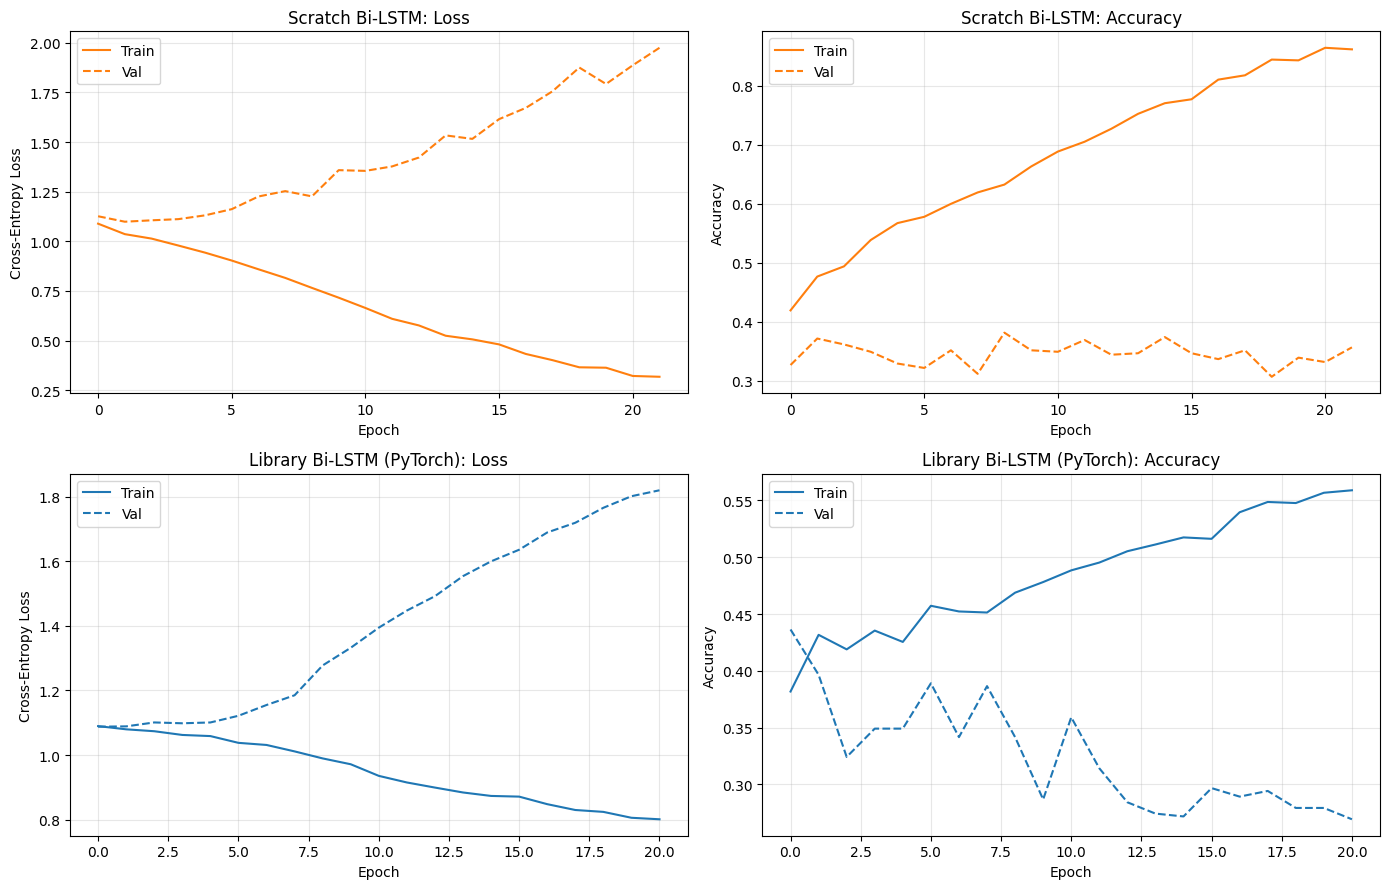

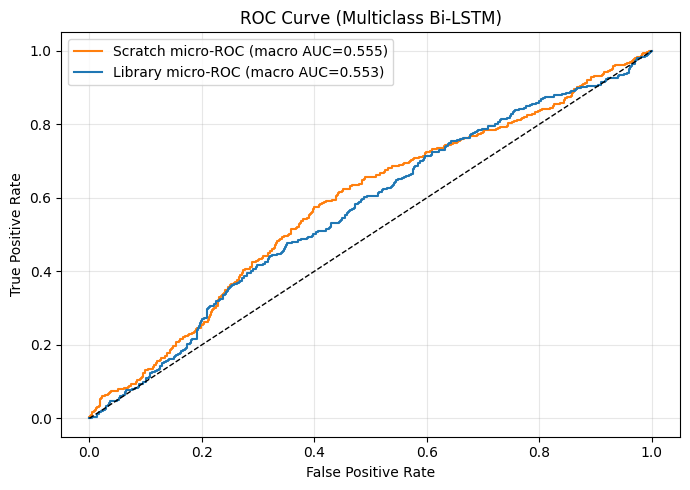

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    log_loss,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    mean_squared_error,
    r2_score,
    roc_curve,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

WINDOW_SIZE = 14
DATA_PATH = '../CLASSIFY-SnP_daily_update_AMZN_features_with_target.csv'
FEATURE_PATH = '../CLASSIFY-AMZN_methods_all_in_one.csv'
TARGET_COL = 'Target_Return_7d'

UP_THRESHOLD = 0.03
DOWN_THRESHOLD = -0.03

# --------------------------
# 1) Load data and features
# --------------------------
df = pd.read_csv(DATA_PATH)
feature_df = pd.read_csv(FEATURE_PATH)

requested_features = [
    'ma_gap_20', 'vol_10', 'vol_20',
    'lower_wick', 'upper_wick',
    'ret_1',
    'range_pct',
    'co_ret',
    'ret_5'
]
allowed_features = feature_df['feature'].tolist() if 'feature' in feature_df.columns else []
feature_cols = [c for c in requested_features if c in allowed_features and c in df.columns and c != TARGET_COL]
missing = [c for c in requested_features if c not in feature_cols]
if missing:
    print('Missing features:', missing)

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.sort_values('Date').reset_index(drop=True)

model_df = df[feature_cols + [TARGET_COL]].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print(f'Rows after cleaning: {len(model_df)}')
print(f'Number of features used: {len(feature_cols)}')
print('Features used:', feature_cols)

# --------------------------------
# 2) Build sliding window features (3D: samples x timesteps x features)
# --------------------------------
def map_target_3class(y_values, up_thr=0.03, down_thr=-0.03):
    y_cls = np.full_like(y_values, 1, dtype=np.int64)
    y_cls[y_values > up_thr] = 2
    y_cls[y_values < down_thr] = 0
    return y_cls

CLASS_LABELS = {0: 'Downtrend', 1: 'Sideway', 2: 'Uptrend'}
N_CLASSES = 3

X_raw = model_df[feature_cols].values.astype(np.float64)
y_raw_cont = model_df[TARGET_COL].values.astype(np.float64)
y_raw = map_target_3class(y_raw_cont, up_thr=UP_THRESHOLD, down_thr=DOWN_THRESHOLD)

print('\nTarget mapping:')
print(f'  > {UP_THRESHOLD:.2f} -> Uptrend (2)')
print(f'  < {DOWN_THRESHOLD:.2f} -> Downtrend (0)')
print('  otherwise -> Sideway (1)')
print('Class distribution:', {CLASS_LABELS[k]: int((y_raw == k).sum()) for k in sorted(CLASS_LABELS)})

# 3D windows: (samples, WINDOW_SIZE, n_features)
def make_windows_3d(x_values, y_values, window_size=14):
    Xw, yw = [], []
    for i in range(window_size, len(x_values)):
        Xw.append(x_values[i - window_size:i])
        yw.append(y_values[i])
    return np.array(Xw, dtype=np.float64), np.array(yw, dtype=np.int64)

X_win, y_win = make_windows_3d(X_raw, y_raw, window_size=WINDOW_SIZE)
n_features = X_win.shape[2]

# Chronological split 80/10/10 (train/val/test)
split_train = int(len(X_win) * 0.8)
split_val = int(len(X_win) * 0.9)
X_train_raw, X_val_raw, X_test_raw = X_win[:split_train], X_win[split_train:split_val], X_win[split_val:]
y_train, y_val, y_test = y_win[:split_train], y_win[split_train:split_val], y_win[split_val:]

# Standardize per feature across all timesteps (using train stats)
x_mean = X_train_raw.reshape(-1, n_features).mean(axis=0)
x_std = X_train_raw.reshape(-1, n_features).std(axis=0)
x_std = np.where(x_std == 0, 1.0, x_std)

X_train = (X_train_raw - x_mean) / x_std
X_val = (X_val_raw - x_mean) / x_std
X_test = (X_test_raw - x_mean) / x_std

print(f'\nX_train shape: {X_train.shape}  (samples, timesteps, features)')
print(f'X_val   shape: {X_val.shape}')
print(f'X_test  shape: {X_test.shape}')

# Compute class weights for imbalanced data
class_weights = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_train)
print(f'Class weights: {dict(zip([CLASS_LABELS[i] for i in range(3)], np.round(class_weights, 3)))}')

# --------------------------------------------------
# 3) Bi-LSTM from Scratch (NumPy) — with Adam optimizer & mini-batch
# --------------------------------------------------
class BiLSTMScratchClassifier:
    """Multiclass Bi-LSTM classifier from scratch using NumPy.
    Architecture:
        Forward LSTM  -> h_fwd (last timestep)
        Backward LSTM -> h_bwd (last timestep of reversed sequence = first timestep)
        Concatenate [h_fwd; h_bwd] -> Dense (2*hidden -> n_classes) -> Softmax

    Features:
    - Adam optimizer
    - Mini-batch training
    - Learning rate decay
    - Class-weighted cross-entropy loss
    - Validation-based early stopping
    """
    def __init__(self, input_size, hidden_size, n_classes, lr=0.001, epochs=100,
                 batch_size=64, seed=42, patience=15, lr_decay=0.98):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.n_classes = n_classes
        self.lr = lr
        self.initial_lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.patience = patience
        self.lr_decay = lr_decay
        self.loss_history = []
        self.acc_history = []
        self.val_loss_history = []
        self.val_acc_history = []

        rng = np.random.RandomState(seed)
        D = input_size
        H = hidden_size
        scale_ih = np.sqrt(2.0 / (D + H))
        scale_hh = np.sqrt(2.0 / (H + H))

        # Forward LSTM: gates = [i, f, g, o] (input, forget, cell-candidate, output)
        # W_fwd: (D, 4H),  U_fwd: (H, 4H),  b_fwd: (4H,)
        self.W_fwd = rng.randn(D, 4 * H).astype(np.float64) * scale_ih
        self.U_fwd = rng.randn(H, 4 * H).astype(np.float64) * scale_hh
        self.b_fwd = np.zeros(4 * H, dtype=np.float64)
        # Initialize forget gate bias to 1 for better gradient flow
        self.b_fwd[H:2*H] = 1.0

        # Backward LSTM: same structure
        self.W_bwd = rng.randn(D, 4 * H).astype(np.float64) * scale_ih
        self.U_bwd = rng.randn(H, 4 * H).astype(np.float64) * scale_hh
        self.b_bwd = np.zeros(4 * H, dtype=np.float64)
        self.b_bwd[H:2*H] = 1.0

        # Output layer: 2*H -> n_classes (concatenation of fwd + bwd)
        scale_out = np.sqrt(2.0 / (2 * H + n_classes))
        self.W_out = rng.randn(2 * H, n_classes).astype(np.float64) * scale_out
        self.b_out = np.zeros(n_classes, dtype=np.float64)

        # Adam optimizer state
        self._param_names = [
            'W_fwd', 'U_fwd', 'b_fwd',
            'W_bwd', 'U_bwd', 'b_bwd',
            'W_out', 'b_out'
        ]
        self._grad_names = [
            'dW_fwd', 'dU_fwd', 'db_fwd',
            'dW_bwd', 'dU_bwd', 'db_bwd',
            'dW_out', 'db_out'
        ]
        self._adam_m = {name: np.zeros_like(getattr(self, name)) for name in self._param_names}
        self._adam_v = {name: np.zeros_like(getattr(self, name)) for name in self._param_names}
        self._adam_t = 0
        self._beta1 = 0.9
        self._beta2 = 0.999
        self._adam_eps = 1e-8

    def _sigmoid(self, x):
        x = np.clip(x, -500, 500)
        return 1.0 / (1.0 + np.exp(-x))

    def _tanh(self, x):
        return np.tanh(x)

    def _softmax(self, x):
        x_stable = x - np.max(x, axis=-1, keepdims=True)
        e = np.exp(x_stable)
        return e / np.sum(e, axis=-1, keepdims=True)

    def _lstm_forward_pass(self, X_seq, W, U, b):
        """Single-direction LSTM forward pass.
        X_seq: (T, D)
        Returns: h_last, c_last, cache
        """
        T, D = X_seq.shape
        H = self.hidden_size
        h = np.zeros(H, dtype=np.float64)
        c = np.zeros(H, dtype=np.float64)

        cache = {'x': [], 'h_prev': [], 'c_prev': [],
                 'i': [], 'f': [], 'g': [], 'o': [], 'c': [], 'h': []}

        for t in range(T):
            x_t = X_seq[t]
            h_prev = h.copy()
            c_prev = c.copy()

            # gates: [i, f, g, o] all in one matmul
            gates = x_t @ W + h_prev @ U + b   # (4H,)
            i_t = self._sigmoid(gates[:H])
            f_t = self._sigmoid(gates[H:2*H])
            g_t = self._tanh(gates[2*H:3*H])
            o_t = self._sigmoid(gates[3*H:4*H])

            c = f_t * c_prev + i_t * g_t
            h = o_t * self._tanh(c)

            cache['x'].append(x_t)
            cache['h_prev'].append(h_prev)
            cache['c_prev'].append(c_prev)
            cache['i'].append(i_t)
            cache['f'].append(f_t)
            cache['g'].append(g_t)
            cache['o'].append(o_t)
            cache['c'].append(c.copy())
            cache['h'].append(h.copy())

        return h, c, cache

    def _lstm_backward_pass(self, cache, dh_last, W, U):
        """Single-direction LSTM backward pass (BPTT).
        Returns gradients dW, dU, db.
        """
        T = len(cache['x'])
        H = self.hidden_size

        dW = np.zeros_like(W)
        dU = np.zeros_like(U)
        db = np.zeros(4 * H, dtype=np.float64)

        dh = dh_last.copy()
        dc = np.zeros(H, dtype=np.float64)

        for t in reversed(range(T)):
            x_t = cache['x'][t]
            h_prev = cache['h_prev'][t]
            c_prev = cache['c_prev'][t]
            i_t = cache['i'][t]
            f_t = cache['f'][t]
            g_t = cache['g'][t]
            o_t = cache['o'][t]
            c_t = cache['c'][t]

            # h = o * tanh(c)
            tanh_c = self._tanh(c_t)
            do = dh * tanh_c
            dc += dh * o_t * (1 - tanh_c ** 2)

            # c = f * c_prev + i * g
            di = dc * g_t
            df = dc * c_prev
            dg = dc * i_t
            dc_prev = dc * f_t

            # Gate pre-activations
            di_raw = di * i_t * (1 - i_t)
            df_raw = df * f_t * (1 - f_t)
            dg_raw = dg * (1 - g_t ** 2)
            do_raw = do * o_t * (1 - o_t)

            dgates = np.concatenate([di_raw, df_raw, dg_raw, do_raw])  # (4H,)

            dW += np.outer(x_t, dgates)
            dU += np.outer(h_prev, dgates)
            db += dgates

            # Propagate to previous timestep
            dh = dgates @ U.T
            dc = dc_prev

        return dW, dU, db

    def _forward_single(self, X_seq):
        """Bi-LSTM forward pass for a single sequence. X_seq shape: (T, D).
        Returns: probs, h_concat, (cache_fwd, cache_bwd)
        """
        # Forward direction
        h_fwd, c_fwd, cache_fwd = self._lstm_forward_pass(
            X_seq, self.W_fwd, self.U_fwd, self.b_fwd)

        # Backward direction (reverse the sequence)
        X_rev = X_seq[::-1].copy()
        h_bwd, c_bwd, cache_bwd = self._lstm_forward_pass(
            X_rev, self.W_bwd, self.U_bwd, self.b_bwd)

        # Concatenate last hidden states
        h_concat = np.concatenate([h_fwd, h_bwd])  # (2H,)

        # Output layer
        logits = h_concat @ self.W_out + self.b_out
        probs = self._softmax(logits)
        return probs, h_concat, (cache_fwd, cache_bwd)

    def _backward_single(self, caches, h_concat, probs, y_onehot, sample_weight=1.0):
        """Backward pass for a single sequence. Returns gradients dict."""
        cache_fwd, cache_bwd = caches
        H = self.hidden_size

        # Output layer gradients
        d_logits = (probs - y_onehot) * sample_weight
        dW_out = np.outer(h_concat, d_logits)
        db_out = d_logits.copy()

        # Gradient w.r.t. concatenated hidden
        dh_concat = d_logits @ self.W_out.T  # (2H,)
        dh_fwd = dh_concat[:H]
        dh_bwd = dh_concat[H:]

        # Backward through forward LSTM
        dW_fwd, dU_fwd, db_fwd = self._lstm_backward_pass(
            cache_fwd, dh_fwd, self.W_fwd, self.U_fwd)

        # Backward through backward LSTM
        dW_bwd, dU_bwd, db_bwd = self._lstm_backward_pass(
            cache_bwd, dh_bwd, self.W_bwd, self.U_bwd)

        grads = {
            'dW_fwd': dW_fwd, 'dU_fwd': dU_fwd, 'db_fwd': db_fwd,
            'dW_bwd': dW_bwd, 'dU_bwd': dU_bwd, 'db_bwd': db_bwd,
            'dW_out': dW_out, 'db_out': db_out
        }
        return grads

    def _adam_update(self, grads):
        """Adam optimizer update."""
        self._adam_t += 1
        for pname, gname in zip(self._param_names, self._grad_names):
            g = grads[gname]
            gnorm = np.linalg.norm(g)
            if gnorm > 5.0:
                g = g * (5.0 / gnorm)

            self._adam_m[pname] = self._beta1 * self._adam_m[pname] + (1 - self._beta1) * g
            self._adam_v[pname] = self._beta2 * self._adam_v[pname] + (1 - self._beta2) * (g ** 2)
            m_hat = self._adam_m[pname] / (1 - self._beta1 ** self._adam_t)
            v_hat = self._adam_v[pname] / (1 - self._beta2 ** self._adam_t)
            setattr(self, pname, getattr(self, pname) - self.lr * m_hat / (np.sqrt(v_hat) + self._adam_eps))

    def fit(self, X, y, X_val=None, y_val=None, class_weights=None):
        """Train on X: (N, T, D), y: (N,) integer labels."""
        N = X.shape[0]
        eps = 1e-9

        if class_weights is not None:
            sample_w = np.array([class_weights[yi] for yi in y])
        else:
            sample_w = np.ones(N)

        best_val_loss = np.inf
        patience_counter = 0
        best_params = None

        for epoch in range(self.epochs):
            self.lr = self.initial_lr * (self.lr_decay ** epoch)

            indices = np.random.permutation(N)
            total_loss = 0.0
            correct = 0

            for start in range(0, N, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                grad_accum = None

                for i in batch_idx:
                    y_oh = np.zeros(self.n_classes, dtype=np.float64)
                    y_oh[y[i]] = 1.0
                    probs, h_concat, caches = self._forward_single(X[i])
                    loss_i = -np.sum(y_oh * np.log(probs + eps)) * sample_w[i]
                    total_loss += loss_i
                    correct += (np.argmax(probs) == y[i])
                    grads = self._backward_single(caches, h_concat, probs, y_oh, sample_weight=sample_w[i])

                    if grad_accum is None:
                        grad_accum = {k: v.copy() for k, v in grads.items()}
                    else:
                        for k in grad_accum:
                            grad_accum[k] += grads[k]

                bs = len(batch_idx)
                for k in grad_accum:
                    grad_accum[k] /= bs

                self._adam_update(grad_accum)

            avg_loss = total_loss / N
            acc = correct / N
            self.loss_history.append(avg_loss)
            self.acc_history.append(acc)

            # Validation monitoring
            if X_val is not None:
                val_probs = self.predict_proba(X_val)
                val_loss = 0.0
                val_correct = 0
                for i in range(len(X_val)):
                    y_oh_v = np.zeros(self.n_classes, dtype=np.float64)
                    y_oh_v[y_val[i]] = 1.0
                    val_loss += -np.sum(y_oh_v * np.log(val_probs[i] + eps))
                    val_correct += (np.argmax(val_probs[i]) == y_val[i])
                val_loss /= len(X_val)
                val_acc = val_correct / len(X_val)
                self.val_loss_history.append(val_loss)
                self.val_acc_history.append(val_acc)

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                    best_params = {name: getattr(self, name).copy() for name in self._param_names}
                else:
                    patience_counter += 1

                if (epoch + 1) % 10 == 0 or epoch == 0:
                    print(f'  Epoch {epoch+1}/{self.epochs} — loss: {avg_loss:.4f}, acc: {acc:.4f} | val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f} (lr={self.lr:.6f})')

                if patience_counter >= self.patience:
                    print(f'  Early stopping at epoch {epoch+1} (no val improvement for {self.patience} epochs)')
                    break
            else:
                if (epoch + 1) % 10 == 0 or epoch == 0:
                    print(f'  Epoch {epoch+1}/{self.epochs} — loss: {avg_loss:.4f}, acc: {acc:.4f} (lr={self.lr:.6f})')

        if best_params is not None:
            for name in self._param_names:
                setattr(self, name, best_params[name])
            print(f'  Restored best model (val_loss={best_val_loss:.4f})')

    def predict_proba(self, X):
        N = X.shape[0]
        all_probs = np.zeros((N, self.n_classes), dtype=np.float64)
        for i in range(N):
            probs, _, _ = self._forward_single(X[i])
            all_probs[i] = probs
        return all_probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)


# Subsample training data for scratch model (full BPTT is slow)
MAX_SCRATCH_TRAIN = 1500
rng_sub = np.random.RandomState(42)
if len(X_train) > MAX_SCRATCH_TRAIN:
    sub_idx = rng_sub.choice(len(X_train), MAX_SCRATCH_TRAIN, replace=False)
    sub_idx.sort()
    X_train_scratch = X_train[sub_idx]
    y_train_scratch = y_train[sub_idx]
    print(f'\nSubsampled training set for scratch Bi-LSTM: {len(X_train)} -> {MAX_SCRATCH_TRAIN}')
else:
    X_train_scratch = X_train
    y_train_scratch = y_train

HIDDEN_SIZE = 48
EPOCHS_SCRATCH = 120

print(f'\nTraining Bi-LSTM from scratch (hidden={HIDDEN_SIZE}, epochs={EPOCHS_SCRATCH}, Adam + mini-batch) ...')
scratch_model = BiLSTMScratchClassifier(
    input_size=n_features, hidden_size=HIDDEN_SIZE, n_classes=N_CLASSES,
    lr=0.002, epochs=EPOCHS_SCRATCH, batch_size=64, seed=42,
    patience=20, lr_decay=0.995
)
scratch_model.fit(X_train_scratch, y_train_scratch,
                  X_val=X_val, y_val=y_val,
                  class_weights=class_weights)
y_prob_scratch = scratch_model.predict_proba(X_test)
y_pred_scratch = scratch_model.predict(X_test)

# -------------------------------------
# 4) Bi-LSTM Library (PyTorch) — with dropout, scheduler, early stopping, class weights
# -------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nPyTorch device: {device}')

class BiLSTMClassifierTorch(nn.Module):
    def __init__(self, input_size, hidden_size, n_classes, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, n_classes)  # *2 for bidirectional

    def forward(self, x):
        out, _ = self.lstm(x)       # out: (batch, seq_len, 2*hidden)
        out = out[:, -1, :]          # last timestep (contains fwd last + bwd first)
        out = self.dropout(out)
        return self.fc(out)

HIDDEN_LIB = 64
EPOCHS_LIB = 150
BATCH_SIZE = 64
LR_LIB = 0.001
PATIENCE_LIB = 20

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

lib_model = BiLSTMClassifierTorch(n_features, HIDDEN_LIB, N_CLASSES, num_layers=2, dropout=0.3).to(device)

# Class-weighted cross-entropy loss
cw_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=cw_tensor)

optimizer = optim.Adam(lib_model.parameters(), lr=LR_LIB, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8, verbose=False)

lib_loss_history = []
lib_acc_history = []
lib_val_loss_history = []
lib_val_acc_history = []

best_val_loss_lib = float('inf')
patience_counter_lib = 0
best_model_state = None

print(f'Training PyTorch Bi-LSTM (hidden={HIDDEN_LIB}, epochs={EPOCHS_LIB}, 2-layer, dropout=0.3, class-weighted) ...')
for epoch in range(EPOCHS_LIB):
    lib_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = lib_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lib_model.parameters(), 5.0)
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        total += xb.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    lib_loss_history.append(avg_loss)
    lib_acc_history.append(acc)

    # Validation monitoring
    lib_model.eval()
    with torch.no_grad():
        val_logits = lib_model(X_val_t)
        val_loss = nn.CrossEntropyLoss(weight=cw_tensor)(val_logits, y_val_t).item()
        val_acc = (val_logits.argmax(dim=1) == y_val_t).float().mean().item()
    lib_val_loss_history.append(val_loss)
    lib_val_acc_history.append(val_acc)

    scheduler.step(val_loss)

    if val_loss < best_val_loss_lib:
        best_val_loss_lib = val_loss
        patience_counter_lib = 0
        best_model_state = copy.deepcopy(lib_model.state_dict())
    else:
        patience_counter_lib += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch+1}/{EPOCHS_LIB} — loss: {avg_loss:.4f}, acc: {acc:.4f} | val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f} (lr={current_lr:.6f})')

    if patience_counter_lib >= PATIENCE_LIB:
        print(f'  Early stopping at epoch {epoch+1} (no val improvement for {PATIENCE_LIB} epochs)')
        break

# Restore best model
if best_model_state is not None:
    lib_model.load_state_dict(best_model_state)
    print(f'  Restored best model (val_loss={best_val_loss_lib:.4f})')

lib_model.eval()
with torch.no_grad():
    logits_test = lib_model(X_test_t)
    y_prob_lib = torch.softmax(logits_test, dim=1).cpu().numpy()
    y_pred_lib = logits_test.argmax(dim=1).cpu().numpy()

# ------------------------
# 5) Metrics and outputs
# ------------------------
classes = np.array([0, 1, 2])

loss_scratch = log_loss(y_test, y_prob_scratch, labels=classes)
loss_lib = log_loss(y_test, y_prob_lib, labels=classes)

cm_scratch = confusion_matrix(y_test, y_pred_scratch, labels=classes)
cm_lib = confusion_matrix(y_test, y_pred_lib, labels=classes)

acc_scratch = accuracy_score(y_test, y_pred_scratch)
acc_lib = accuracy_score(y_test, y_pred_lib)

precision_scratch = precision_score(y_test, y_pred_scratch, average='macro', zero_division=0)
precision_lib = precision_score(y_test, y_pred_lib, average='macro', zero_division=0)

recall_scratch = recall_score(y_test, y_pred_scratch, average='macro', zero_division=0)
recall_lib = recall_score(y_test, y_pred_lib, average='macro', zero_division=0)

f1_scratch = f1_score(y_test, y_pred_scratch, average='macro', zero_division=0)
f1_lib = f1_score(y_test, y_pred_lib, average='macro', zero_division=0)

mse_scratch = mean_squared_error(y_test, y_pred_scratch)
mse_lib = mean_squared_error(y_test, y_pred_lib)
rmse_scratch = np.sqrt(mse_scratch)
rmse_lib = np.sqrt(mse_lib)
r2_scratch = r2_score(y_test, y_pred_scratch)
r2_lib = r2_score(y_test, y_pred_lib)

def multiclass_macro_specificity(cm):
    total = np.sum(cm)
    specs = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp
        tn = total - (tp + fp + fn)
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return float(np.mean(specs))

specificity_scratch = multiclass_macro_specificity(cm_scratch)
specificity_lib = multiclass_macro_specificity(cm_lib)

print('=== Loss ===')
print(f'Scratch log loss: {loss_scratch:.6f}')
print(f'Library log loss: {loss_lib:.6f}')

print('\n=== Confusion Matrix (rows=true, cols=pred) ===')
print('Class order:', [CLASS_LABELS[c] for c in classes])
print('Scratch:\n', cm_scratch)
print('Library:\n', cm_lib)

p_s, r_s, f_s, sup_s = precision_recall_fscore_support(y_test, y_pred_scratch, labels=classes, zero_division=0)
p_l, r_l, f_l, sup_l = precision_recall_fscore_support(y_test, y_pred_lib, labels=classes, zero_division=0)

print('\n=== Per-Class Metrics (Scratch) ===')
for i, c in enumerate(classes):
    print(f"{CLASS_LABELS[c]:<10} | Precision: {p_s[i]:.4f} | Recall: {r_s[i]:.4f} | F1: {f_s[i]:.4f} | Support: {sup_s[i]}")

print('\n=== Per-Class Metrics (Library) ===')
for i, c in enumerate(classes):
    print(f"{CLASS_LABELS[c]:<10} | Precision: {p_l[i]:.4f} | Recall: {r_l[i]:.4f} | F1: {f_l[i]:.4f} | Support: {sup_l[i]}")

print('\n=== Metrics Summary (Macro) ===')
print(f'Accuracy - Scratch: {acc_scratch:.4f} | Library: {acc_lib:.4f}')
print(f'Precision - Scratch: {precision_scratch:.4f} | Library: {precision_lib:.4f}')
print(f'Recall - Scratch: {recall_scratch:.4f} | Library: {recall_lib:.4f}')
print(f'Specificity - Scratch: {specificity_scratch:.4f} | Library: {specificity_lib:.4f}')
print(f'F1-score - Scratch: {f1_scratch:.4f} | Library: {f1_lib:.4f}')

print('\n=== Additional Numeric Metrics (Label-Encoded) ===')
print(f'MSE - Scratch: {mse_scratch:.4f} | Library: {mse_lib:.4f}')
print(f'RMSE - Scratch: {rmse_scratch:.4f} | Library: {rmse_lib:.4f}')
print(f'R² - Scratch: {r2_scratch:.4f} | Library: {r2_lib:.4f}')

# ROC & AUC (multiclass OvR + micro-curve for plotting)
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc_s = roc_auc_score(y_test_bin, y_prob_scratch, average='macro', multi_class='ovr')
roc_auc_l = roc_auc_score(y_test_bin, y_prob_lib, average='macro', multi_class='ovr')

fpr_s, tpr_s, _ = roc_curve(y_test_bin.ravel(), y_prob_scratch.ravel())
fpr_l, tpr_l, _ = roc_curve(y_test_bin.ravel(), y_prob_lib.ravel())

print('\n=== ROC & AUC (Multiclass OvR Macro AUC) ===')
print(f'Scratch AUC: {roc_auc_s:.4f}')
print(f'Library AUC: {roc_auc_l:.4f}')

# ---------------------------------------------------------
# 6) Performance curves (loss + accuracy) and ROC
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Scratch: Loss
axes[0, 0].plot(scratch_model.loss_history, label='Train', color='tab:orange')
if scratch_model.val_loss_history:
    axes[0, 0].plot(scratch_model.val_loss_history, label='Val', color='tab:orange', linestyle='--')
axes[0, 0].set_title('Scratch Bi-LSTM: Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Cross-Entropy Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Scratch: Accuracy
axes[0, 1].plot(scratch_model.acc_history, label='Train', color='tab:orange')
if scratch_model.val_acc_history:
    axes[0, 1].plot(scratch_model.val_acc_history, label='Val', color='tab:orange', linestyle='--')
axes[0, 1].set_title('Scratch Bi-LSTM: Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Library: Loss
axes[1, 0].plot(lib_loss_history, label='Train', color='tab:blue')
axes[1, 0].plot(lib_val_loss_history, label='Val', color='tab:blue', linestyle='--')
axes[1, 0].set_title('Library Bi-LSTM (PyTorch): Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Cross-Entropy Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Library: Accuracy
axes[1, 1].plot(lib_acc_history, label='Train', color='tab:blue')
axes[1, 1].plot(lib_val_acc_history, label='Val', color='tab:blue', linestyle='--')
axes[1, 1].set_title('Library Bi-LSTM (PyTorch): Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ROC Curve (micro-averaged one-vs-rest)
plt.figure(figsize=(7, 5))
plt.plot(fpr_s, tpr_s, label=f'Scratch micro-ROC (macro AUC={roc_auc_s:.3f})', color='tab:orange')
plt.plot(fpr_l, tpr_l, label=f'Library micro-ROC (macro AUC={roc_auc_l:.3f})', color='tab:blue')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve (Multiclass Bi-LSTM)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()